In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [33]:
class BugState(TypedDict):
    error: str
    category: str
    solution: str

In [34]:
def classify_error(state: BugState):
    error = state["error"].lower()
    if "syntaxerror" in error:
        category = "error"
    elif "modulenotfounderror" in error or "importerror" in error:
        category = "import"
    elif "typeerror" in error or "valueerror" in error:
        category = "runtime"
    else:
        category = "general"
    return {"category":category}

In [35]:
import re

In [36]:
def syntax_node(state: BugState):
    return {
        "solution":"Check missing colon, brackets or indentation"
    }

In [37]:
def import_node(state: BugState):
    error = state["error"]
    match = re.search(r"No module named ['\"]?([a-zA-Z0-9_\-\.]+)['\"]?",error)
    if match:
        package = match.group(1).split(".")[0]
        solution = f"Install missing package: pip install {package}"
    else:
        solution = "Install missing package"
    return {"solution":solution}

In [38]:
def runtime_node(state: BugState):
    return {
        "solution":"Check variavles types and input values"
    }

In [39]:
def general_node(state: BugState):
    return {
        "solution":"Review error message"
    }

In [40]:
workflow = StateGraph(BugState)
workflow.add_node("classifier",classify_error)
workflow.add_node("syntax",syntax_node)
workflow.add_node("import",import_node)
workflow.add_node("runtime",runtime_node)
workflow.add_node("general",general_node)
workflow.set_entry_point("classifier")

In [41]:
def route_error(state):
    return state["category"]

In [42]:
workflow.add_conditional_edges("classifier",route_error,
                               {
                                   "syntax":"syntax",
                                   "import":"import",
                                   "runtime":"runtime",
                                   "general":"general"
                               })

In [43]:
workflow.add_edge("syntax",END)
workflow.add_edge("import",END)
workflow.add_edge("runtime",END)
workflow.add_edge("general",END)

In [44]:
app = workflow.compile()

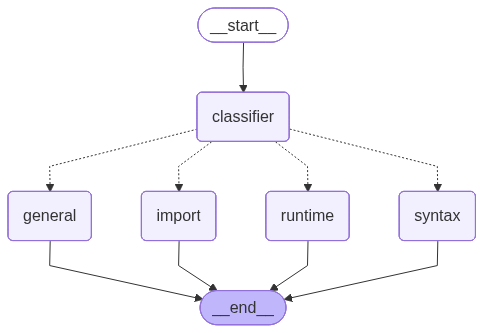

In [45]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [46]:
result = app.invoke({
    "error": "ModuleNotFoundError: No module named numpy"
})

print(result["solution"])

Install missing package: pip install numpy
